# RSI Strategy Backtest

**What this notebook does:**

Tests an RSI (Relative Strength Index) mean-reversion strategy on historical stock data:
- **BUY** (go long) when RSI drops **below** the oversold threshold (default 30)
- **SELL** (go short) when RSI rises **above** the overbought threshold (default 70)
- **CASH** (flat) when RSI is between the two thresholds

It then compares: did this strategy beat just holding the stock?

*Source: Based on the "Sharp Research" YouTube quant series.*

## Setup & Imports

4 Libraries
- `numpy` — fast math on arrays
- `yfinance` — free historical price data from Yahoo Finance
- `matplotlib` — plotting / charting
- `pandas` — DataFrames (spreadsheet-like tables for data manipulation)

In [1]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

## Configuration

Change these variables to test different assets or RSI parameters:
- `TICKER` — which asset to backtest
- `RSI_LENGTH` — RSI lookback period (standard is 14)
- `OVERBOUGHT` / `OVERSOLD` — threshold levels that trigger signals
- `LOOKBACK` — how many trading days to use for analysis

In [2]:
TICKER = 'SPY'
RSI_LENGTH = 14
OVERBOUGHT = 70
OVERSOLD = 30
LOOKBACK = 10000

## Step 1: Download Price Data

Downloads the full price history from Yahoo Finance (since 1993), then trims to the last `LOOKBACK` rows. Using a large lookback (10,000) ensures the RSI calculation has enough warm-up data to stabilize — Wilder's smoothing is recursive and needs history to be accurate.

In [3]:
def get_data(ticker=TICKER):
    df = yf.download(ticker, start="1993-01-01")
    df.columns = df.columns.get_level_values(0)  # flatten multi-level column headers
    return df.iloc[-LOOKBACK:, :]                 # only return the subset we're interested in

## Step 2: Calculate RSI

**How RSI works, step by step:**

1. `diff()` — calculate the daily price change (today's close minus yesterday's)
2. Separate into **gains** (positive changes) and **losses** (negative changes, flipped to positive)
3. Smooth both with **Wilder's smoothing** — an exponential moving average where `alpha = 1 / length`
4. `RS = avg_gain / avg_loss` — the Relative Strength ratio
5. `RSI = 100 - (100 / (1 + RS))` — converts RS into a 0–100 scale

RSI near **100** = price has been rising consistently (overbought).
RSI near **0** = price has been falling consistently (oversold).

Wilder's smoothing (`ewm(alpha=1/length)`) is the industry standard — this matches what you'd see on TradingView or any broker platform.

In [4]:
def add_RSI(df, length=RSI_LENGTH):
    price_change = df['Close'].diff()

    gain = price_change.where(price_change > 0, 0)       # keep gains, zero out losses
    loss = -price_change.where(price_change < 0, 0)       # keep losses as positive values

    avg_gain = gain.ewm(alpha=1/length, adjust=False).mean()  # Wilder's smoothing
    avg_loss = loss.ewm(alpha=1/length, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    df['RSI'] = rsi

    # plot RSI with overbought/oversold lines
    plt.plot(df['RSI'])
    plt.axhline(OVERBOUGHT, color='red')
    plt.axhline(OVERSOLD, color='green')

    return df.dropna()

## Step 3: Generate Trading Signals (Hold Until Flip)

The rule:
- RSI crosses **below** oversold (30) → enter **long**, hold until opposite signal
- RSI crosses **above** overbought (70) → enter **short**, hold until opposite signal

Unlike the original v1 version (which snaps to cash the moment RSI leaves the extreme zone), this version **holds the position** until the opposite threshold fires. You're always in a trade once the first signal hits — no cash state.

This requires a loop instead of `np.where` because each row needs to "remember" the previous position. Slower than vectorized numpy, but negligible on daily data.

`.shift(1)` avoids look-ahead bias, same as before.

In [5]:
def add_strategy(df, overbought=OVERBOUGHT, oversold=OVERSOLD):
    df['Strategy'] = 0
    df['Strategy'] = np.where(df['RSI'] > overbought, -1,       # overbought → short
                     np.where(df['RSI'] < oversold, 1, 0))       # oversold → long, else cash

    df['Strategy'] = df['Strategy'].shift(1)  # avoid look-ahead bias
    return df

## Step 4: Calculate & Compare Returns

Computes cumulative returns for both buy-and-hold and the RSI strategy, then plots them.

**The math, step by step:**
1. `pct_change()` — calculates daily percentage change (e.g., 100 → 102 = +2%)
2. `1 + daily_return` — converts to a growth factor (e.g., +2% becomes 1.02)
3. `cumprod()` — multiplies all growth factors together cumulatively
4. `- 1` — converts back to percentage terms

When Strategy = -1 (short), the daily return is flipped. When Strategy = 0 (cash), the return contribution is zero.

In [6]:
def test_strategy(df):
    df['Asset_Returns'] = (1 + df['Close'].pct_change().fillna(0)).cumprod() - 1
    df['Strategy_Returns'] = (1 + (df['Close'].pct_change() * df['Strategy']).fillna(0)).cumprod() - 1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Strategy Cumulative'])
    plt.title(f'RSI Strategy vs {TICKER}')

    return df

## Step 5: Run the Backtest

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume  \
Date                                                                   
2026-04-17  710.140015  712.390015  705.760010  706.140015  70661900   
2026-04-20  708.719971  709.909973  706.140015  708.780029  43546800   
2026-04-21  704.080017  711.280029  702.640015  710.280029  58941400   
2026-04-22  711.210022  711.450012  708.219971  709.150024  42473500   
2026-04-23  711.000000  711.284973  709.260010  709.500000   4347683   

Price             RSI  Strategy  Asset_Returns  Strategy_Returns  
Date                                                              
2026-04-17  73.591111      -1.0      28.167057          1.645182  
2026-04-20  72.205093      -1.0      28.108732          1.650471  
2026-04-21  67.717231      -1.0      27.918159          1.667824  
2026-04-22  70.728047       0.0      28.211004          1.667824  
2026-04-23  70.519414      -1.0      28.202378          1.668611  


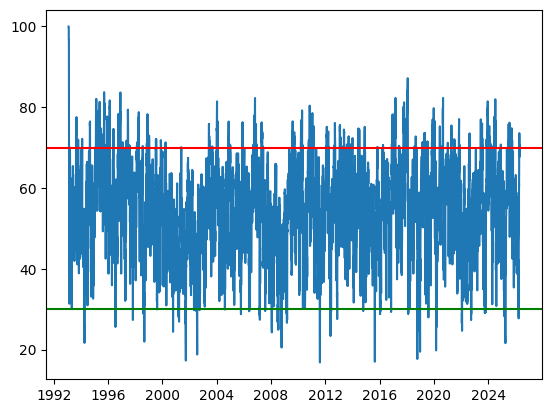

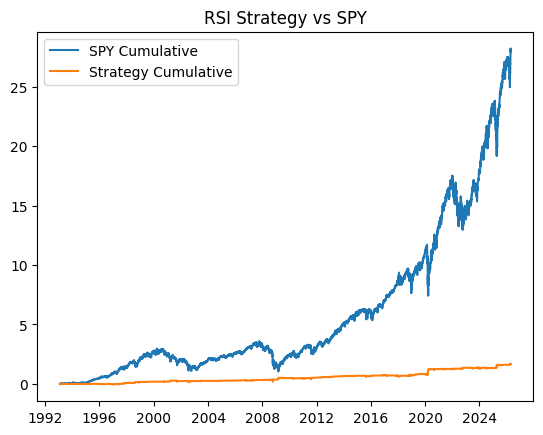

In [7]:
def main():
    df = get_data()
    df = add_RSI(df)
    df = add_strategy(df)
    df = test_strategy(df)
    print(df.tail())
    return df

df = main()